# Copyright Information

This lab is a modification of materials from\
© MIT Introduction to Deep Learning\
http://introtodeeplearning.com

# Lab 1: Intro to TensorFlow and Music Generation with RNNs

In this lab, you'll get exposure to using TensorFlow and learn how it can be used for solving deep learning tasks. Go through the code and run each cell. Along the way, you'll encounter several ***TODO*** blocks -- follow the instructions to fill them out before running those cells and continuing.


# Part 1: Intro to TensorFlow

## 0.1 Install TensorFlow

TensorFlow is a software library extensively used in machine learning. Here we'll learn how computations are represented and how to define a simple neural network in TensorFlow. In this lab we'll be using TensorFlow 2, which affords great flexibility and the ability to imperatively execute operations, just like in Python. You'll notice that TensorFlow 2 is quite similar to Python in its syntax and imperative execution. Let's install TensorFlow and a couple of dependencies.


In [ ]:
import tensorflow as tf

# Download and import the MIT Introduction to Deep Learning package
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl

import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 1.1 Why is TensorFlow called TensorFlow?

TensorFlow is called 'TensorFlow' because it handles the flow (node/mathematical operation) of Tensors, which are data structures that you can think of as multi-dimensional arrays. Tensors are represented as n-dimensional arrays of base dataTypes such as a string or integer -- they provide a way to generalize vectors and matrices to higher dimensions.

The ```shape``` of a Tensor defines its number of dimensions and the size of each dimension. The ```rank``` of a Tensor provides the number of dimensions (n-dimensions) -- you can also think of this as the Tensor's order or degree.

Let's first look at 0-d Tensors, of which a scalar is an example:

In [ ]:
sport = tf.constant("Tennis", tf.string)
number = tf.constant(1.41421356237, tf.float64)

print(f"`sport` is a {tf.rank(sport).numpy()}-d Tensor")
print(f"`number` is a {tf.rank(number).numpy()}-d Tensor")

`sport` is a 0-d Tensor
`number` is a 0-d Tensor


### Understanding `tf.constant`, data types, and tensor rank

`tf.constant` creates a TensorFlow tensor with a fixed value. We use it when we want data that should not change while our program runs, such as the string `\"Tennis\"` or the number `1.414...` above. Its most common arguments are:

- `value`: the Python object (number, string, list, etc.) whose contents you want to store.
- `dtype`: *(optional)* the TensorFlow data type to cast the value to. If you omit it, TensorFlow tries to infer a type for you.
- `shape`: *(optional)* lets you reshape the created tensor without changing its values.
- `name`: *(optional)* a label that can make debugging easier.

TensorFlow uses explicit data types to control the precision and storage size of each tensor. Two types you will see often are `tf.float64` (64-bit floating point numbers, useful for high-precision math) and `tf.int64` (64-bit integers, good when you need to count or index large ranges). Choosing the right dtype helps TensorFlow allocate memory efficiently and avoid accidental rounding errors.

To check how many dimensions a tensor has, we call `tf.rank`. Scalars, such as the ones we just created, have rank 0; 1-D lists have rank 1, 2-D tables have rank 2, and so on. Knowing the rank and dtype of your tensors makes it much easier to debug shape mismatches.

Vectors and lists can be used to create 1-d Tensors:

In [ ]:
sports = tf.constant(["Tennis", "Basketball"], tf.string)
numbers = tf.constant([3.141592, 1.414213, 2.71821], tf.float64)

sports_rank = tf.rank(sports).numpy()
sports_shape = tf.shape(sports)

numbers_rank = tf.rank(numbers).numpy()
numbers_shape = tf.shape(numbers)

print(f"`sports` is a {sports_rank}-d Tensor with shape: {sports_shape}")
print(f"`numbers` is a {numbers_rank}-d Tensor with shape: {numbers_shape}")

`sports` is a 1-d Tensor with shape: [2]
`numbers` is a 1-d Tensor with shape: [3]


Next we consider creating 2-d (i.e., matrices) and higher-rank Tensors.

**Your turn:** in the next cell, build a 2D tensor that has 4 rows and 2 columns of integers. After you create it, add an `assert` that confirms the tensor really has shape `(4, 2)`. Practicing these quick checks now will save you time when models become more complex.

In [ ]:
### Defining higher-order Tensors ###

# TODO: Define a 2-d Tensor with 4 rows and 2 columns of integers
array_2D = [
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8]
]
matrix = tf.constant(array_2D, dtype=tf.int32)

assert isinstance(matrix, tf.Tensor), "matrix must be a tf Tensor object"
assert tf.rank(matrix).numpy() == 2, "matrix must have rank 2"
assert tf.shape(matrix).numpy().tolist() == [4, 2], "matrix must be shape 4x2"

print("matrix tensor:\n", matrix.numpy())
print("shape:", tf.shape(matrix).numpy())
print("dtype:", matrix.dtype)

matrix tensor:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
shape: [4 2]
dtype: <dtype: 'int32'>


For examples, in future labs involving image processing and computer vision, we will use 4-d Tensors. Here the dimensions correspond to the number of example images in our batch, image height, image width, and the number of color channels.

The code below constructs a batch of **3 images**, each of which is **4 pixels high by 4 pixels wide** with **3 color channels**. TensorFlow stores an image as a grid of pixel values, where each pixel is represented by a small list. For RGB images, that list has three numbers: red, green, and blue intensity. Values are commonly in the range 0–255 when the data type is an integer (`tf.int64` here), or between 0.0 and 1.0 when using floating point types.

Because we keep the batch dimension first, TensorFlow knows we are feeding multiple images at once. The shape `(3, 4, 4, 3)` reads as: 3 images → each has 4 rows → each row has 4 columns → each pixel has 3 color channels. Many real-world datasets use exactly this layout, so getting comfortable with it now will make loading and preprocessing image data feel much more natural.

```python
t4D = [ # list of images
        [ # image 1
          [ # first row of pixels in image
            [255,20,113], [195, 202, 80], [50, 202, 150],[100, 150, 10]
          ],
          [ # second row of pixels in image
            [255,20,113], [195, 202, 80], [50, 202, 150],[100, 150, 10]
          ],
          [ # third row of pixels in image
            [255,20,113], [195, 202, 80], [50, 202, 150],[100, 150, 10]
          ],
          [ # fourth row of pixels in image
            [255,20,113], [195, 202, 80], [50, 202, 150],[100, 150, 10]
          ]
        ],
        [ # image 2
            # same structure as image 1
        ],
        [ # image 3
            # same structure as image 1
        ]
      ]

input_images = tf.constant(t4D, tf.int64)
```

Now practice creating your own empty image batch. In the next cell, initialize a 4D tensor using `tf.zeros`. This function fills a tensor of the shape you specify with zeros, which is handy when you need a starting point before loading real data.

Use it like this: `tf.zeros(shape, dtype=...)`. The `shape` argument is a Python tuple or list describing the desired dimensions, and `dtype` controls the numeric type of each element (for example, `tf.float32` for pixel intensities stored as decimals).

Example `tz.zeros([200, 20, 20], tf.int64)` returns a 3 dimensional grid.  You could think of this as a list of 200 20x20 matrices or tables.

Once you run the cell, print the resulting tensor's shape to double-check it matches what you expected.

In [ ]:
'''TODO: Define a 4-d Tensor.'''
# Use tf.zeros to initialize a 4-d Tensor of zeros with size 10 x 256 x 256 x 3.
# Think of as 10 images where each image is 256x256 with channels for R, G & B.

images = tf.zeros((10, 256, 256, 3), dtype=tf.float32)

assert isinstance(images, tf.Tensor), "matrix must be a tf Tensor object"
assert tf.rank(images).numpy() == 4, "matrix must be of rank 4"
assert tf.shape(images).numpy().tolist() == [10, 256, 256, 3], "matrix is incorrect shape"

As you have seen, the ```shape``` of a Tensor provides the number of elements in each Tensor dimension. The ```shape``` is quite useful, and we'll use it often. You can also use slicing to access subtensors within a higher-rank Tensor:

In [ ]:
row_vector = matrix[1]
column_vector = matrix[:,1]
scalar = matrix[0, 1]

print(f"`row_vector`: {row_vector.numpy()}")
print(f"`column_vector`: {column_vector.numpy()}".format())
print(f"`scalar`: {scalar.numpy()}")

`row_vector`: [3 4]
`column_vector`: [2 4 6 8]
`scalar`: 2


## 1.2 Computations on Tensors

A convenient way to think about and visualize computations in TensorFlow is in terms of graphs. We can define this graph in terms of Tensors, which hold data, and the mathematical operations that act on these Tensors in some order. Let's look at a simple example, and define this computation using TensorFlow:

![alt text](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/2025/lab1/img/add-graph.png)

In [ ]:
# Create the nodes in the graph, and initialize values
a = tf.constant(15)
b = tf.constant(61)

# Add them!
c1 = tf.add(a,b)
c2 = a + b # TensorFlow overrides the "+" operation so that it is able to act on Tensors
print(c1)
print(c2)

tf.Tensor(76, shape=(), dtype=int32)
tf.Tensor(76, shape=(), dtype=int32)


Notice how we've created a computation graph consisting of TensorFlow operations, and how the output is a Tensor with value 76 -- we've just created a computation graph consisting of operations, and it's executed them and given us back the result.

Matrix operations show up everywhere in deep learning because they let us apply the same calculation to many values at once. At a high level:

- **Matrix addition** combines two tensors of the same shape by adding corresponding entries. In TensorFlow you can write `tf.add(a, b)` or simply `a + b`.
- **Matrix subtraction** works the same way but subtracts element-wise. Use `tf.subtract(a, b)` or the shorthand `a - b`.
- **Matrix multiplication** is a little different: each output entry is the dot product of a row from the left matrix and a column from the right matrix. TensorFlow provides `tf.matmul(a, b)` for true matrix multiplication, and also lets you write `a * b` when you want element-wise multiplication (`tf.multiply`).

When both operands are tensors, Python's `+`, `-`, and `*` operators automatically call these TensorFlow implementations. That means the examples above build TensorFlow operations behind the scenes, keeping our computation graph consistent while still looking like familiar algebra.

In [ ]:
### Defining Tensor computations ###

# Construct a simple computation function
def func(a,b):
  '''TODO: Define the operation for c, d, e (use tf.add, tf.subtract, tf.multiply).'''
  c = tf.add(a, b)
  d = tf.subtract(b, 1)
  e = tf.multiply(c, d)
  return e

Now, we can call this function to execute the computation graph given some inputs `a,b`:

In [ ]:
# Consider example values for a,b
a, b = 1.5, 2.5
# Execute the computation
e_out = func(a,b)
print(e_out.numpy())

6.0


Notice how our output is a Tensor with value defined by the output of the computation, and that the output has no shape as it is a single scalar value.

Let's try this same function on a set of tensors that are 1 dimensional.

In [ ]:
tensor_one = tf.constant([4,5,6])
tensor_two = tf.constant([1,2,3])
tensor_three = func(tensor_one, tensor_two)
'''
Intuiation of what is happening here ...
c = [4,5,6] + [1,2,3] -> [5,7,9]
d = [1,2,3] - [1,1,1] -> [0,1,2]
e = [5,7,9] x [0,1,2] -> [0,7,18]
'''
print(tensor_three.numpy())

[ 0  7 18]


## 1.3 Neural networks in TensorFlow
We can also define neural networks in TensorFlow. TensorFlow uses a high-level API called [Keras](https://www.tensorflow.org/guide/keras) that provides a powerful, intuitive framework for building and training deep learning models.

Let's first consider the example of a simple perceptron defined by just one dense layer: $ y = \sigma(Wx + b)$, where $W$ represents a matrix of weights, $b$ is a bias, $x$ is the input, $\sigma$ is the sigmoid activation function, and $y$ is the output. We can also visualize this operation using a graph:

![alt text](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/2025/lab1/img/computation-graph-2.png)

Tensors can flow through abstract types called [```Layers```](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Layer)-- the building blocks of neural networks. ```Layers``` implement common neural networks operations, and are used to update weights, compute losses, and define inter-layer connectivity. We will first define a ```Layer``` to implement the simple perceptron defined above.

Below, we create a custom class called `OurDenseLayer`. It **inherits** from `tf.keras.layers.Layer`, which means it starts with all of the functionality that any Keras layer already has (keeping track of weights, connecting to other layers, saving models, and more). By building on top of this base class, we only have to specify what is unique about our layer instead of rewriting all of the supporting code from scratch.

Every Keras layer follows the same life cycle:

1. `__init__` saves any configuration values that the layer needs later. In our example we store the number of output nodes so that we know how wide the layer should be.
2. `build(self, input_shape)` is called the first time the layer sees real data. TensorFlow passes in the shape of that data so we can create learnable parameters of the right size. Here, we add a weight matrix `W` and a bias vector `b`, both initialized randomly.
3. `call(self, x)` defines the actual computation that happens during a forward pass. When we receive an input tensor `x`, we compute the linear combination `z = xW + b` (implemented with `tf.matmul`) and then squeeze the result through the sigmoid activation to produce the final output `y`.

Thinking through this sequence helps us understand both the code and the mathematics it represents: once `build` has created the weights, `call` reuses them every time the layer processes new data.


In [ ]:
### Defining a network Layer ###

# n_output_nodes: number of output nodes
# input_shape: shape of the input
# x: input to the layer

class OurDenseLayer(tf.keras.layers.Layer):
  def __init__(self, n_output_nodes):
    super(OurDenseLayer, self).__init__()
    self.n_output_nodes = n_output_nodes

  def build(self, input_shape):
    d = int(input_shape[-1])
    # Define and initialize parameters: a weight matrix W and bias b
    # Note that parameter initialization is random!
    self.W = self.add_weight(name="weight", shape=[d, self.n_output_nodes]) # note the dimensionality
    self.b = self.add_weight(name="bias", shape=[1, self.n_output_nodes]) # note the dimensionality

  def call(self, x):
    '''TODO: define the operation for z (hint: use tf.matmul, matrix multiplication)'''
    z = tf.matmul(x, self.W) + self.b

    '''TODO: define the operation for out (hint: use tf.sigmoid)'''
    y = tf.sigmoid(z)
    return y

# Since layer parameters are initialized randomly, we will set a random seed for reproducibility
tf.keras.utils.set_random_seed(1)
layer = OurDenseLayer(3)
layer.build((1,2))
x_input = tf.constant([[1,2.]], shape=(1,2))
y = layer.call(x_input)

# test the output!
print(y.numpy())
mdl.lab1.test_custom_dense_layer_output(y)

[[0.27064407 0.1826951  0.50374055]]
[PASS] test_custom_dense_layer_output


True

Conveniently, TensorFlow has defined a number of ```Layers``` that are commonly used in neural networks, for example a [```Dense```](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense?version=stable) layer. Now, instead of using a single ```Layer``` to define our simple neural network, we'll use the  [`Sequential`](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras/Sequential) model from Keras and a single [`Dense` ](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras/layers/Dense) layer to define our network. With the `Sequential` API, you can readily create neural networks by stacking together layers like building blocks.

The `Sequential` class behaves like an empty list of layers. We create the container first, then "append" layers to it using `model.add(...)`. Each layer we add will automatically feed its output into the next layer.

A `Dense` layer is Keras' name for a fully connected layer. When we construct one, we specify at least the number of output units (`units=...`) and, optionally, an activation function such as `activation='sigmoid'`. Behind the scenes, Keras creates the weight matrix `W` and bias vector `b` for us just as we did manually above.

Example:
```python
my_model = Sequential()
my_layer = Dense(units=num_nodes, activation='sigmoid')
my_model.add(my_layer)
```

Putting this together, we will: (1) instantiate a dense layer with the desired number of outputs and activation, and (2) add that layer to our sequential model so that it becomes the first (and only) step in the network.


In [ ]:
### Defining a neural network using the Sequential API ###

# Import relevant packages
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Define the number of outputs
n_output_nodes = 3

# First define the model
model = Sequential()

'''TODO: Define a dense (fully connected) layer to compute z'''
# Remember: dense layers are defined by the parameters W and b!
# You can read more about the initialization of W and b in the TF documentation :)
# https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense?version=stable
dense_layer = Dense(n_output_nodes, activation='sigmoid')

# Add the dense layer to the model
model.add(dense_layer)


That's it! We've defined our model using the Sequential API. Now, we can test it out using an example input:

Use `model.call` to do this.

When you call `model.call(x_input)`, you explicitly run the `call` method that we described earlier—it applies each layer in order and returns the prediction. Keras also lets you use the shorthand `model(x_input)`. Under the hood, this triggers the exact same `call` method so the results are identical. The shorter form is convenient, but seeing `model.call(...)` reminds us that we are invoking the network's forward pass directly.


In [ ]:
# Test model with example input
x_input = tf.constant([[1,2.]], shape=(1,2))

'''TODO: feed input into the model and predict the output!'''
model_output = model(x_input)
print(model_output.numpy())
print(model(x_input).numpy())

[[0.18752205 0.23909675 0.3213029 ]]
[[0.18752205 0.23909675 0.3213029 ]]


In addition to defining models using the `Sequential` API, we can also define neural networks by directly subclassing the [`Model`](https://www.tensorflow.org/api_docs/python/tf/keras/Model?version=stable) class, which groups layers together to enable model training and inference. The `Model` class captures what we refer to as a "model" or as a "network". Using Subclassing, we can create a class for our model, and then define the forward pass through the network using the `call` function. Subclassing affords the flexibility to define custom layers, custom training loops, custom activation functions, and custom models. Let's define the same neural network as above now using Subclassing rather than the `Sequential` model.

In [ ]:
### Defining a model using subclassing ###

from tensorflow.keras import Model
from tensorflow.keras.layers import Dense

class SubclassModel(tf.keras.Model):

  # In __init__, we define the Model's layers
  def __init__(self, n_output_nodes):
    super(SubclassModel, self).__init__()
    '''TODO: Our model consists of a single Dense layer. Define this layer.'''
    '''         Use sigmoid as the activation function.                    '''
    self.dense_layer = tf.keras.layers.Dense(n_output_nodes, activation='sigmoid')

  # In the call function, we define the Model's forward pass.
  def call(self, inputs):
    return self.dense_layer(inputs)

Just like the model we built using the `Sequential` API, let's test out our `SubclassModel` using an example input.



In [ ]:
n_output_nodes = 3
model = SubclassModel(n_output_nodes)

x_input = tf.constant([[1,2.]], shape=(1,2))

print(model.call(x_input).numpy())

[[0.82794297 0.15568398 0.567044  ]]


Importantly, Subclassing affords us a lot of flexibility to define custom models. For example, we can use boolean arguments in the `call` function to specify different network behaviors, for example different behaviors during training and inference. Let's suppose under some instances we want our network to simply output the input, without any perturbation. We define a boolean argument `isidentity` to control this behavior:

In [ ]:
### Defining a model using subclassing and specifying custom behavior ###

from tensorflow.keras import Model
from tensorflow.keras.layers import Dense

class IdentityModel(tf.keras.Model):

  # As before, in __init__ we define the Model's layers
  # Since our desired behavior involves the forward pass, this part is unchanged
  def __init__(self, n_output_nodes):
    super(IdentityModel, self).__init__()
    self.dense_layer = tf.keras.layers.Dense(n_output_nodes, activation='sigmoid')

  '''TODO: Implement the behavior where the network outputs the input,
    unchanged, under control of the isidentity argument. In other words if
    isidentity is True, return the inputs unaltered.  If isidentity is False,
    reutrn the result of passing the inputs through the dense layer '''
  def call(self, inputs, isidentity=False):
    if isidentity:
        return inputs
    return self.dense_layer(inputs)

Let's test this behavior:

In [ ]:
n_output_nodes = 3
model = IdentityModel(n_output_nodes)

x_input = tf.constant([[1,2.]], shape=(1,2))
'''TODO: pass the input into the model and call with and without the input identity option.'''
out_activate = model(x_input, isidentity=False)
out_identity = model(x_input, isidentity=True)

print("Network output with activation: {}; network identity output: {}".format(out_activate.numpy(), out_identity.numpy()))

Network output with activation: [[0.5746787  0.6182241  0.88219965]]; network identity output: [[1. 2.]]


Now that we have learned how to define `Layers` as well as neural networks in TensorFlow using both the `Sequential` and Subclassing APIs, we're ready to turn our attention to how to actually implement network training with backpropagation.

## 1.4 Automatic differentiation (why it matters)

**Goal:** Build a *mental model* for what happens during `model.fit`.

- **What’s a loss?** A single number that measures “how wrong” the model is.
- **What’s a gradient?** The *slope* of the loss with respect to each trainable weight.  \
  If slope is positive, nudge the weight down; if negative, nudge it up.
- **What’s automatic differentiation?** TensorFlow records operations as you compute the loss, then
  automatically applies the chain rule to get gradients for you.
- **What does the optimizer do?** Uses those gradients to update weights to make the loss smaller.

You will:
1. Use `tf.GradientTape` to get the derivative of a simple function (no rules memorized).
2. Watch a scalar value *walk* toward a target using gradient descent.
3. See the Keras equivalent where `model.fit` does everything for you.

In [ ]:
### Gradient computation with GradientTape ###

# y = x^2
# Example: x = 3.0
x = tf.Variable(3.0)

# Initiate the gradient tape
with tf.GradientTape() as tape:
  # Define the function
  y = x * x

# Access the gradient -- derivative of y with respect to x
dy_dx = tape.gradient(y, x)
print("x =", x.numpy(), "  y=x^2 =", y.numpy(), "  dy/dx =", dy_dx.numpy())  # expect 6.0

assert dy_dx.numpy() == 6.0

x = 3.0   y=x^2 = 9.0   dy/dx = 6.0


In training neural networks, we use differentiation and stochastic gradient descent (SGD) to optimize a loss function. Now that we have a sense of how `GradientTape` can be used to compute and access derivatives, we will look at an example where we use automatic differentiation and SGD to find the minimum of $L=(x-x_f)^2$. Here $x_f$ is a variable for a desired value we are trying to optimize for; $L$ represents a loss that we are trying to  minimize. While we can clearly solve this problem analytically ($x_{min}=x_f$), considering how we can compute this using `GradientTape` sets us up nicely for future labs where we use gradient descent to optimize entire neural network losses.

Initializing x = -1.1012201309204102


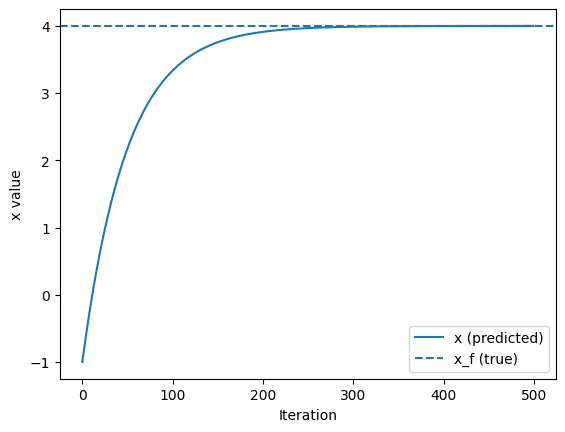

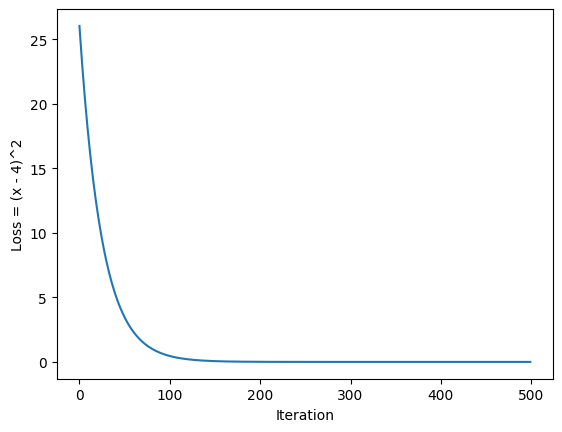

In [ ]:
### Function minimization with automatic differentiation and SGD ###

x = tf.Variable(tf.random.normal([1]))
print("Initializing x =", float(x.numpy()[0]))

learning_rate = 1e-2
history_x = []
history_loss = []
x_f = 4.0  # target value

for i in range(500):
  with tf.GradientTape() as tape:
    loss = (x - x_f)**2  # squared error

  grad = tape.gradient(loss, x)        # d(loss)/dx
  x.assign_sub(learning_rate * grad)   # x <- x - lr * grad

  history_x.append(float(x.numpy()[0]))
  history_loss.append(float(loss.numpy()[0]))

plt.figure()
plt.plot(history_x)
plt.axhline(y=x_f, linestyle='--')
plt.legend(['x (predicted)', 'x_f (true)'])
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.show()

plt.figure()
plt.plot(history_loss)
plt.xlabel('Iteration')
plt.ylabel('Loss = (x - 4)^2')
plt.show()

**Keras does this for you:** This is the same idea as our manual loop—Keras computes the loss, automatic differentiation finds gradients, and the optimizer updates weights for you with no calculus and no `GradientTape` required.

In [ ]:
from tensorflow import keras
from keras import layers
import numpy as np

# We'll train a 1-neuron model to output 4 for a constant input 1.
# This is equivalent to learning a single "x" that minimizes (x - 4)^2.
model = keras.Sequential([layers.Dense(1, input_shape=(1,), use_bias=False)])
model.compile(optimizer=keras.optimizers.SGD(1e-2), loss='mse')

X = np.ones((256, 1), dtype=np.float32)  # constant input
y = np.full((256, 1), 4.0, dtype=np.float32)  # target is 4

history = model.fit(X, y, epochs=100, verbose=0)
w = model.layers[0].get_weights()[0][0, 0]
print('Learned value ≈', round(float(w), 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Learned value ≈ 4.0


**Quick Check**
If the gradient is **positive**, should the optimizer move the weight up or down to reduce loss?


Answer:  
1) Down (subtract a positive slope).  
